In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_csv("../data/cleaned/zomato_cleaned.csv",encoding = 'latin-1')
print(df.shape)
df.head()

(41202, 12)


,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


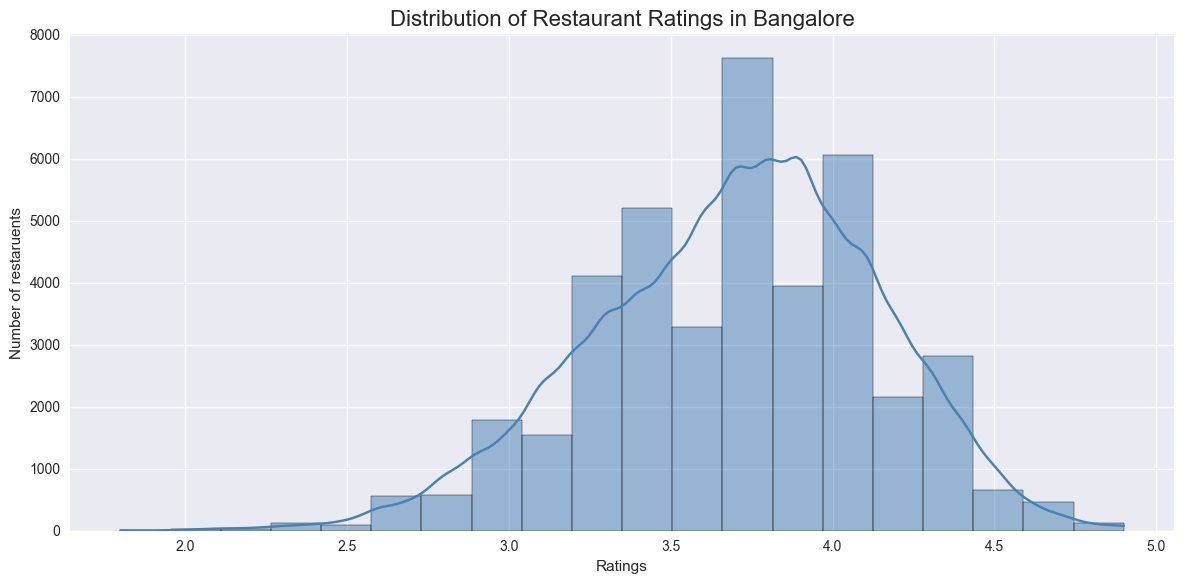

In [6]:
# checking the distribution of ratings of restaruents
sns.histplot(df['rate'],bins = 20, kde = True, color = 'steelblue')
plt.title('Distribution of Restaurant Ratings in Bangalore', fontsize=16)
plt.xlabel("Ratings")
plt.ylabel("Number of restaruents")
plt.tight_layout()
plt.show()

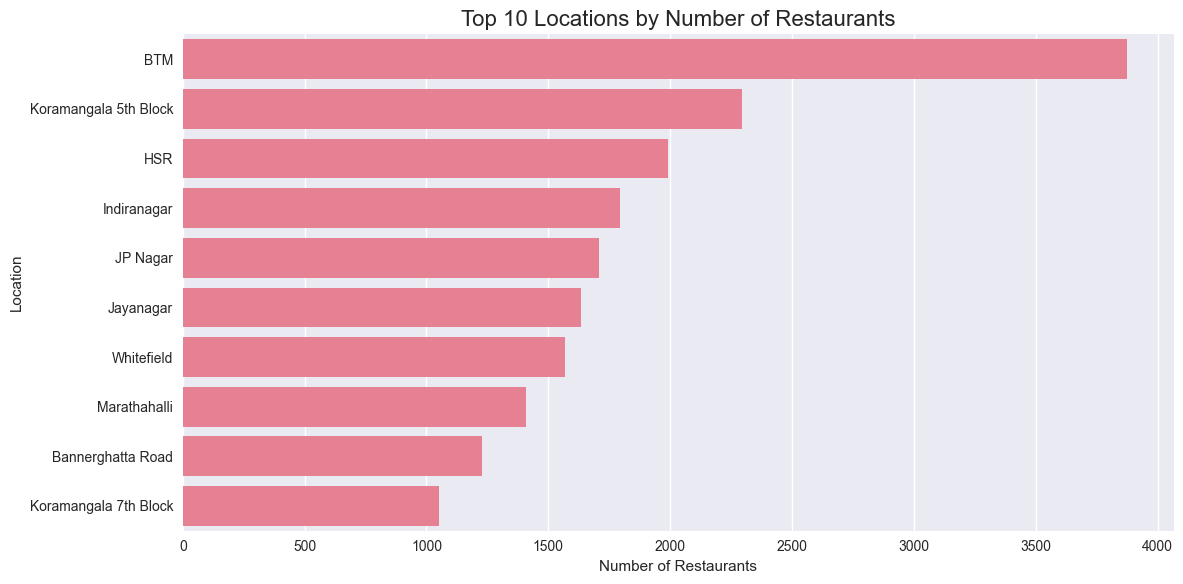

In [10]:
location_count = df['location'].value_counts().head(10)
sns.barplot(x = location_count.values,y = location_count.index)
plt.title('Top 10 Locations by Number of Restaurants',fontsize=16)
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

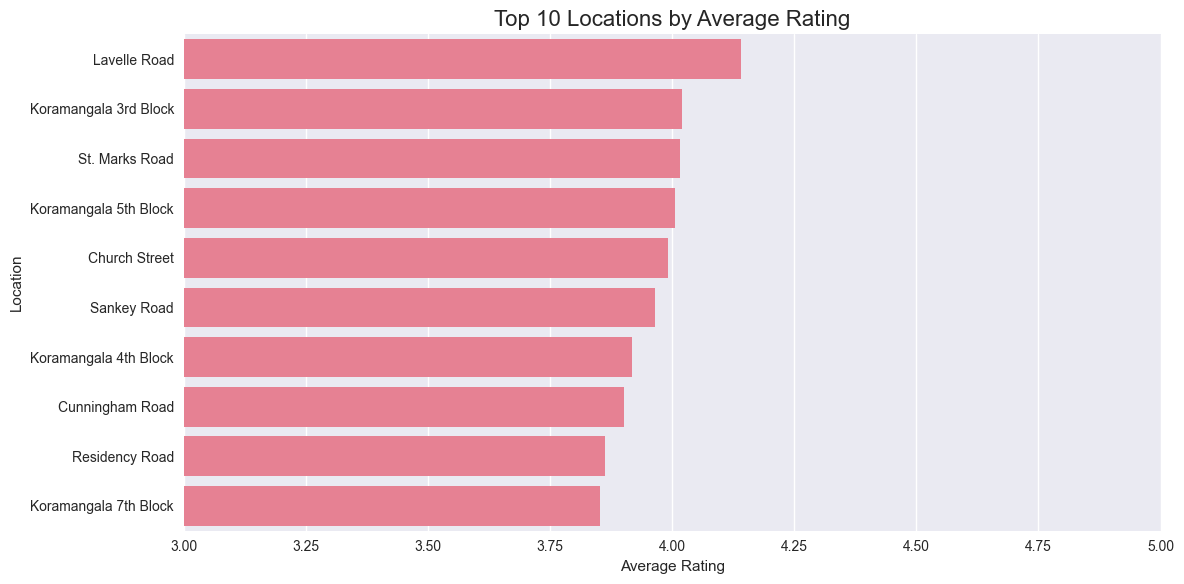

In [11]:
#Relationship between restaruent count(by area) and ratings
avg_rating_loc = df.groupby('location')['rate'].mean().sort_values(ascending = False).head(10)
sns.barplot(x = avg_rating_loc.values, y = avg_rating_loc.index)
plt.title('Top 10 Locations by Average Rating', fontsize=16)
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.xlim(3, 5)
plt.tight_layout()
plt.show()

In [17]:
print('Average rating of restaruents Lavelle Road',df[df['location'] == 'Lavelle Road']['rate'].mean().round(3))
print('Average cost of restaurants in Lavelle Road',df[df['location'] == 'Lavelle Road']['approx_cost(for two people)'].mean().round(3))
print('Average rating of restaruents BTM',df[df['location'] == 'BTM']['rate'].mean().round(3))
print('Average cost of restaurants in BTM',df[df['location'] == 'BTM']['approx_cost(for two people)'].mean().round(3))

Average rating of restaruents Lavelle Road 4.14
Average cost of restaurants in Lavelle Road 1365.021
Average rating of restaruents BTM 3.572
Average cost of restaurants in BTM 418.206


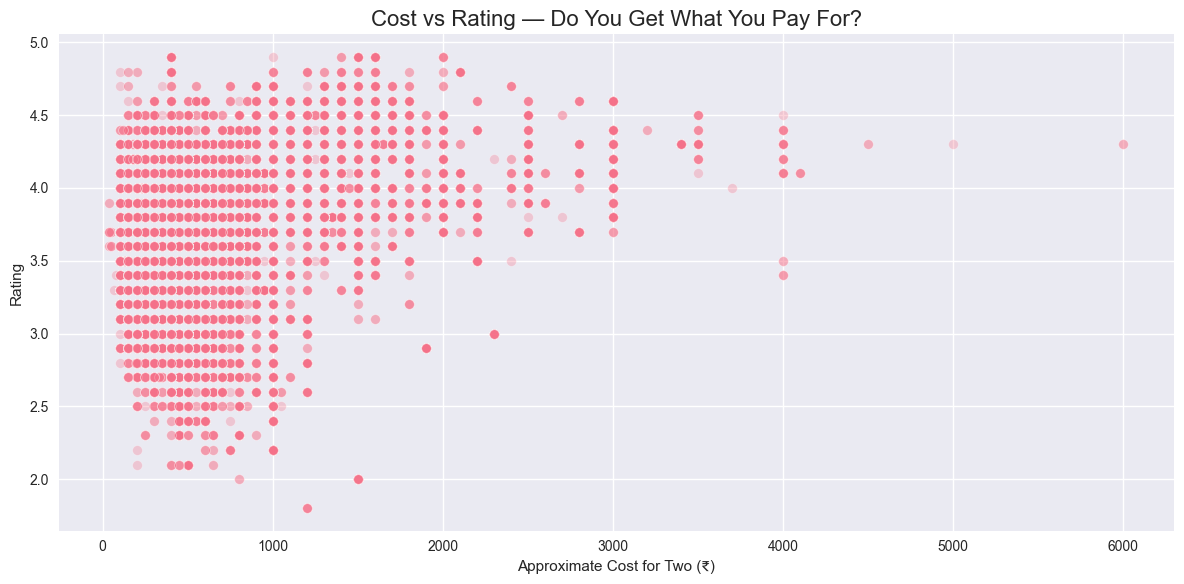

In [25]:
#Cost vs Rating Scatter Plot
sns.scatterplot(data=df,x='approx_cost(for two people)',y='rate',alpha = 0.3)
plt.title('Cost vs Rating — Do You Get What You Pay For?', fontsize=16)
plt.xlabel('Approximate Cost for Two (₹)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()